In [12]:
import numpy as np
import matplotlib.pyplot as plt
def cancor(X, Y):
    """Returns the canonical correlations and directions between the columns of X and Y.

    Aims to be a copy of the R function stats::cancor by centering each matrix, taking
    the QR decompositions, and returning the singular values of Q_X^T @ Q_Y.
    """
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)
    Qx, _ = np.linalg.qr(X)
    Qy, _ = np.linalg.qr(Y)
    return np.linalg.svd(Qx.T @ Qy, compute_uv=False)

def tapered_cancor(X, Y, bandwidth):
    n, p = X.shape

    Xc = X - X.mean(axis=0)
    Yc = Y - Y.mean(axis=0)

    Sxx = (Xc.T @ Xc) / (n - 1)
    Syy = (Yc.T @ Yc) / (n - 1)
    Sxy = (Xc.T @ Yc) / (n - 1)
    # Change taper method here
    T = hard_taper_matrix(p, bandwidth)

    Sxx_tap = T * Sxx
    Syy_tap = T * Syy
    Sxy_tap = T*Sxy
    
    eig_x, Ux = np.linalg.eigh(Sxx_tap)
    eig_y, Uy = np.linalg.eigh(Syy_tap)

    Sxx_invhalf = Ux @ np.diag(1 / np.sqrt(eig_x)) @ Ux.T
    Syy_invhalf = Uy @ np.diag(1 / np.sqrt(eig_y)) @ Uy.T

    M = Sxx_invhalf @ Sxy_tap @ Syy_invhalf

    return np.linalg.svd(M, compute_uv=False)
def band_matrix(p, bandwidth):
    i, j = np.indices((p, p))
    dist = np.abs(i - j)
    B = (dist <= bandwidth).astype(float)
    return B
def ar1_matrix(n, p, phi, rng):
    X = np.zeros((n, p))
    X[:, 0] = rng.standard_normal(n)

    for j in range(1, p):
        eps = np.sqrt(1 - phi**2) * rng.standard_normal(n)
        X[:, j] = phi * X[:, j - 1] + eps

    return X


def taper_matrix(p, bandwidth):
    i, j = np.indices((p, p))
    dist = np.abs(i - j)
    T = np.maximum(0, 1 - dist / bandwidth)
    return T

def hard_taper_matrix(p, bandwidth):
    i, j = np.indices((p, p))
    dist = np.abs(i - j)
    return (dist <= bandwidth).astype(float)
    
def exponential_taper_matrix(p, alpha):
    i, j = np.indices((p, p))
    dist = np.abs(i - j)
    return alpha ** dist



rng = np.random.default_rng()

n = 200
phi = 0.6
p_ratios = np.arange(0.05, 0.951, 0.05)
# Error onyl occurse when I include 2 as a bandwidth
bandwidths = [2,5, 10, 20]
results = {b: [] for b in bandwidths}
ordinary = []

for ratio in p_ratios:
    p = int(np.floor(n * ratio))

    X = ar1_matrix(n, p, phi, rng)
    Y = ar1_matrix(n, p, phi, rng)

    ordinary.append(cancor(X, Y)[0])

    for b in bandwidths:
        rho_hat = abs(tapered_cancor(X, Y, bandwidth=b)[0])
        results[b].append(rho_hat)

plt.figure(figsize=(8, 5))

plt.plot(p_ratios, ordinary, '-o', lw=2, label='ordinary CCA')

for b in bandwidths:
    plt.plot(p_ratios, results[b], '-o', lw=2, label=f'taper bandwidth={b}')

plt.axhline(0, linestyle='--', lw=1)

plt.xlabel('p/n')
plt.ylabel('largest empirical canonical correlation')
plt.title('Effect of covariance tapering on CCA inflation')
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/j1/gy1nzbfd0zg4sbrz26cjyv2c0000gn/T/ipykernel_95761/1290938774.py:35: RuntimeWarning: invalid value encountered in sqrt
  Syy_invhalf = Uy @ np.diag(1 / np.sqrt(eig_y)) @ Uy.T


LinAlgError: SVD did not converge

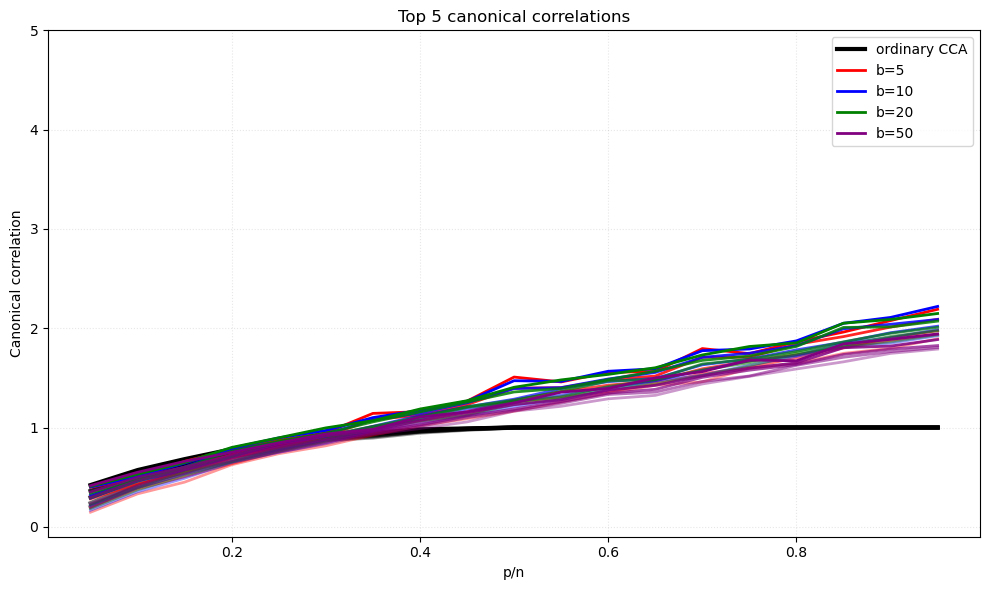

In [13]:
import numpy as np
import matplotlib.pyplot as plt
def tapered_cancor(X, Y, bandwidth):
    n, p = X.shape

    Xc = X - X.mean(axis=0)
    Yc = Y - Y.mean(axis=0)

    Sxx = (Xc.T @ Xc) / (n - 1)
    Syy = (Yc.T @ Yc) / (n - 1)
    Sxy = (Xc.T @ Yc) / (n - 1)

    T = taper_matrix(p, bandwidth)

    Sxx_tap = T * Sxx
    Syy_tap = T * Syy
    Sxy_tap = Sxy
    
    eig_x, Ux = np.linalg.eigh(Sxx_tap)
    eig_y, Uy = np.linalg.eigh(Syy_tap)

    Sxx_invhalf = Ux @ np.diag(1 / np.sqrt(eig_x)) @ Ux.T
    Syy_invhalf = Uy @ np.diag(1 / np.sqrt(eig_y)) @ Uy.T

    M = Sxx_invhalf @ Sxy_tap @ Syy_invhalf

    return np.linalg.svd(M, compute_uv=False)
def band_matrix(p, bandwidth):
    i, j = np.indices((p, p))
    dist = np.abs(i - j)
    B = (dist <= bandwidth).astype(float)
    return B
def ar1_matrix(n, p, phi, rng):
    X = np.zeros((n, p))
    X[:, 0] = rng.standard_normal(n)

    for j in range(1, p):
        eps = np.sqrt(1 - phi**2) * rng.standard_normal(n)
        X[:, j] = phi * X[:, j - 1] + eps

    return X


def taper_matrix(p, bandwidth):
    i, j = np.indices((p, p))
    dist = np.abs(i - j)
    T = np.maximum(0, 1 - dist / bandwidth)
    return T

def hard_taper_matrix(p, bandwidth):
    i, j = np.indices((p, p))
    dist = np.abs(i - j)
    return (dist <= bandwidth).astype(float)
    



rng = np.random.default_rng(123)

n = 200
phi = 0.6
k_track = 5
bandwidths = [5,10,20,50]
ordinary_results = np.zeros((len(p_ratios), k_track))

results = {
    b: np.zeros((len(p_ratios), k_track))
    for b in bandwidths
}

for i, ratio in enumerate(p_ratios):

    p = int(np.floor(n * ratio))

    X = ar1_matrix(n, p, phi, rng)
    Y = ar1_matrix(n, p, phi, rng)

    ordinary_corrs = cancor(X, Y)

    num_to_take = min(k_track, len(ordinary_corrs))
    ordinary_results[i, :num_to_take] = ordinary_corrs[:num_to_take]

    for b in bandwidths:

        corrs = tapered_cancor(X, Y, bandwidth=b)

        num_to_take = min(k_track, len(corrs))
        results[b][i, :num_to_take] = corrs[:num_to_take]
fig, ax = plt.subplots(figsize=(10, 6))

# ordinary CCA
for j in range(k_track):
    ax.plot(
        p_ratios,
        ordinary_results[:, j],
        color="black",
        alpha=1 - 0.15*j,
        lw=3,
        label="ordinary CCA" if j == 0 else None
    )

colors = {
    5: "red",
    10: "blue",
    20: "green",
    50: "purple"
}

for b in bandwidths:

    for j in range(k_track):

        ax.plot(
            p_ratios,
            results[b][:, j],
            color=colors[b],
            alpha=1 - 0.15*j,
            lw=2,
            label=f"b={b}" if j == 0 else None
        )

ax.set_xlabel("p/n")
ax.set_ylabel("Canonical correlation")
ax.set_title("Top 5 canonical correlations")

ax.set_ylim(-0.1, 5)
ax.grid(True, linestyle=":", alpha=0.3)

ax.legend()
plt.tight_layout()
plt.show()